In [4]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Age": [22, 25, 30, 28, 35],
    "Salary": [25000, np.nan, 45000, np.nan, 60000],
    "Gender": ["Male", "Female", "Female", "Male", "Male"],
    "Education": ["Graduate", "Graduate", "Postgraduate", "Graduate", "Postgraduate"]
})

print("Original DataFrame:")
print(df)

df["Salary"] = df["Salary"].fillna(df["Salary"].median())

gender_encoded = pd.get_dummies(df["Gender"], prefix="Gender")

education_map = {
    "High School": 1,
    "Graduate": 2,
    "Postgraduate": 3
}

df["Education"] = df["Education"].map(education_map)

df = pd.concat([df.drop("Gender", axis=1), gender_encoded], axis=1)

print("\nClean DataFrame:")
print(df)

Original DataFrame:
   Age   Salary  Gender     Education
0   22  25000.0    Male      Graduate
1   25      NaN  Female      Graduate
2   30  45000.0  Female  Postgraduate
3   28      NaN    Male      Graduate
4   35  60000.0    Male  Postgraduate

Clean DataFrame:
   Age   Salary  Education  Gender_Female  Gender_Male
0   22  25000.0          2          False         True
1   25  45000.0          2           True        False
2   30  45000.0          3           True        False
3   28  45000.0          2          False         True
4   35  60000.0          3          False         True


   OrderID  OrderDate DeliveryDate  Year  Month  Day  Delivery_Duration  \
0      101 2024-01-10   2024-01-12  2024      1   10                  2   
1      102 2024-02-15   2024-02-18  2024      2   15                  3   
2      103 2024-02-20   2024-02-25  2024      2   20                  5   
3      104 2024-03-05   2024-03-07  2024      3    5                  2   
4      105 2024-03-18   2024-03-22  2024      3   18                  4   

  Order_Type  
0    Weekday  
1    Weekday  
2    Weekday  
3    Weekday  
4    Weekday  


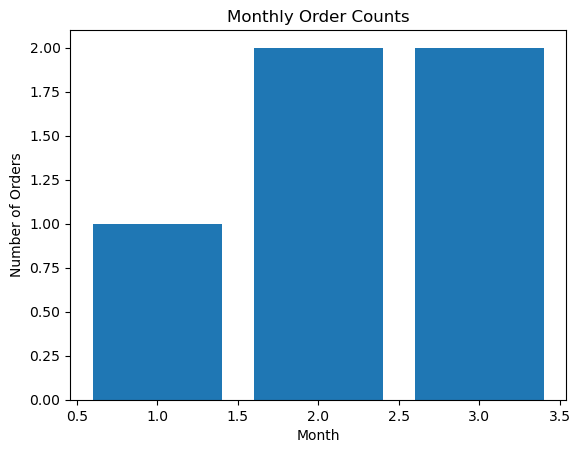

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "OrderID": [101,102,103,104,105],
    "OrderDate": ["2024-01-10","2024-02-15","2024-02-20","2024-03-05","2024-03-18"],
    "DeliveryDate": ["2024-01-12","2024-02-18","2024-02-25","2024-03-07","2024-03-22"]
})

df["OrderDate"] = pd.to_datetime(df["OrderDate"])
df["DeliveryDate"] = pd.to_datetime(df["DeliveryDate"])

df["Year"] = df["OrderDate"].dt.year
df["Month"] = df["OrderDate"].dt.month
df["Day"] = df["OrderDate"].dt.day

df["Delivery_Duration"] = (df["DeliveryDate"] - df["OrderDate"]).dt.days

df["Order_Type"] = df["OrderDate"].dt.day_name().apply(
    lambda x: "Weekend" if x in ["Saturday", "Sunday"] else "Weekday"
)

print(df)

monthly_orders = df["Month"].value_counts().sort_index()

plt.bar(monthly_orders.index, monthly_orders.values)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.title("Monthly Order Counts")
plt.show()

In [6]:
import pandas as pd
import numpy as np

df = pd.DataFrame({
    "Name": ["A","B","C","D","E"],
    "Age": [22, np.nan, 30, 28, np.nan],
    "Salary": [25000, 30000, np.nan, 45000, 50000],
    "City": ["Rajkot", "Ahmedabad", np.nan, "Surat", "Vadodara"]
})

print("Original Dataset:")
print(df)

missing_rows = df.isnull().any(axis=1).sum()
print("\nRows with at least one missing value:", missing_rows)

clean_df = df.dropna()

print("\nDataset after dropping NaN rows:")
print(clean_df)

print("\nOriginal Shape:", df.shape)
print("After Drop Shape:", clean_df.shape)

print("\nTrade-off:")
print("Dropping missing values improves data quality but reduces dataset size and may lead to loss of useful information.")

Original Dataset:
  Name   Age   Salary       City
0    A  22.0  25000.0     Rajkot
1    B   NaN  30000.0  Ahmedabad
2    C  30.0      NaN        NaN
3    D  28.0  45000.0      Surat
4    E   NaN  50000.0   Vadodara

Rows with at least one missing value: 3

Dataset after dropping NaN rows:
  Name   Age   Salary    City
0    A  22.0  25000.0  Rajkot
3    D  28.0  45000.0   Surat

Original Shape: (5, 4)
After Drop Shape: (2, 4)

Trade-off:
Dropping missing values improves data quality but reduces dataset size and may lead to loss of useful information.
